<a href="https://colab.research.google.com/github/sly2997/oil-gas-python-portfolio/blob/main/%20project-1-decline-curve-analysis/volve_dca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decline Curve Analysis — Volve Well 15/9-F-12

Arps decline models fitted to real production data from Equinor's open
Volve dataset (North Sea, 2008–2016).

Headline finding: The hyperbolic fit collapses to b ≈ 0, the well
declines near-exponentially, it is consistent with pressure support from the
water injection in a waterflooded reservoir.

Data used: `Volve_production_data.xlsx` — download from Equinor's Volve
data portal/the Kaggle mirror and uploaded to this Colab session. https://www.kaggle.com/datasets/lamyalbert/volve-production-data?resource=download

Stack: Python, pandas, NumPy, SciPy, matplotlib

In [39]:
#DECLINE CURVE ANALYSIS — VOLVE WELL 15/9-F-12 (REAL FIELD DATA)
#================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Load the data

The Excel file has two sheets; we need `Daily Production Data`
(pandas reads only the first sheet by default, so `sheet_name`
must be explicit). Each row is one well on one calendar day:
oil/gas/water volumes in Sm³, on-stream hours, and pressures.

In [40]:
FILE = "Volve_production_data.xlsx"



In [41]:
from google.colab import drive
drive.mount('/content/drive')

FILE = "/content/drive/MyDrive/Volve_production_data.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import os
print(os.listdir())

['.config', 'volve_f12_dca.png', '.ipynb_checkpoints', 'drive', 'sample_data']


In [43]:
df = pd.read_excel(FILE, sheet_name="Daily Production Data")
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 15634 rows, 24 columns


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


## 2. Filter to a single producer

DCA is a per-well analysis. Well **15/9-F-12** is chosen because it
has the longest continuous history (3,056 of production days, Feb 2008 –
Sep 2016) and the highest cumulative oil of the six producers.
`WELL_TYPE == "OP"` keeps oil-producer rows only.

In [44]:
well = df[(df["NPD_WELL_BORE_NAME"] == "15/9-F-12") &
          (df["WELL_TYPE"] == "OP")].copy()
print(f"Well 15/9-F-12: {len(well)} producing days, "
      f"{well['DATEPRD'].min().date()} to {well['DATEPRD'].max().date()}")

Well 15/9-F-12: 3056 producing days, 2008-02-12 to 2016-09-17


In [45]:
well = df[(df["NPD_WELL_BORE_NAME"] == "15/9-F-12") &
          (df["WELL_TYPE"] == "OP")].copy()
print(f"Well 15/9-F-12: {len(well)} producing days, "
      f"{well['DATEPRD'].min().date()} to {well['DATEPRD'].max().date()}")

Well 15/9-F-12: 3056 producing days, 2008-02-12 to 2016-09-17


## 3. Handle shut-ins and compute true rate

`BORE_OIL_VOL` is the volume for a calendar day. On days when the well
flowed only a few hours (workovers, shut-ins), dividing by a full day
understates its capability and distorts the decline trend.

- Drop days with < 12 hrs on stream (328 of 3,056 days)
- True rate = daily volume ÷ (on-stream hours / 24)
- Convert Sm³/d → bbl/d (× 6.2898)



In [46]:

before = len(well)
well = well[well["ON_STREAM_HRS"] >= 12]          # drop mostly-down days
print(f"Dropped {before - len(well)} low-uptime days (<12 hrs on stream)")

well["oil_rate_Sm3d"] = well["BORE_OIL_VOL"] / (well["ON_STREAM_HRS"] / 24)
well["oil_rate_bpd"] = well["oil_rate_Sm3d"] * 6.2898   # Sm3 -> bbl

Dropped 328 low-uptime days (<12 hrs on stream)


## 4. Monthly averaging and locating the peak

Daily rates are populus; resampling to monthly means reveals the trend.
The fit starts at the **peak month (Dec 2008, ~33,770 bpd)**, not at
first oil — Arps assumes boundary-dominated flow, which doesn't hold
during ramp-up. Fitting from day one would bias every parameter.

In [47]:

monthly = (well.set_index("DATEPRD")["oil_rate_bpd"]
               .resample("MS").mean().dropna())

peak_date = monthly.idxmax()
decline = monthly[monthly.index >= peak_date]     # fit AFTER the peak only
print(f"Peak: {monthly.max():,.0f} bpd in {peak_date:%b %Y}")
print(f"Fitting decline over {len(decline)} months")

# Time axis for fitting: months elapsed since peak (0, 1, 2, ...)
t = np.arange(len(decline), dtype=float)
q = decline.values

Peak: 33,770 bpd in Dec 2008
Fitting decline over 92 months


## 5. Fit Arps exponential and hyperbolic models

`scipy.optimize.curve_fit` finds the parameters (qi, Di, b) minimizing
squared error. Bounds keep b in a physically meaningful range.

Output show the hyperbolic b-parameter drives to ~0, collapsing into
the exponential model (both R² ≈ 0.92). This is a finding, not a
failure: injection-supported wells tend toward exponential decline,
unlike the high-b behaviour typical of unconventional wells.

In [48]:
# ============= CELL 5: FIT ARPS MODELS =============
def exponential(t, qi, di):
    return qi * np.exp(-di * t)

def hyperbolic(t, qi, di, b):
    return qi / (1 + b * di * t) ** (1 / b)

exp_p, _ = curve_fit(exponential, t, q, p0=[q[0], 0.05])
hyp_p, _ = curve_fit(hyperbolic, t, q, p0=[q[0], 0.05, 0.5],
                     bounds=([0, 1e-6, 1e-3], [1e6, 5, 2]))

def r2(actual, pred):
    return 1 - np.sum((actual - pred)**2) / np.sum((actual - np.mean(actual))**2)

r2_e = r2(q, exponential(t, *exp_p))
r2_h = r2(q, hyperbolic(t, *hyp_p))
print(f"Exponential: qi={exp_p[0]:,.0f} bpd, Di={exp_p[1]:.4f}/mo, R²={r2_e:.4f}")
print(f"Hyperbolic:  qi={hyp_p[0]:,.0f} bpd, Di={hyp_p[1]:.4f}/mo, "
      f"b={hyp_p[2]:.2f}, R²={r2_h:.4f}")

Exponential: qi=36,612 bpd, Di=0.0455/mo, R²=0.9198
Hyperbolic:  qi=36,618 bpd, Di=0.0455/mo, b=0.00, R²=0.9198


## 6. Plot: history match

Scatter = actual monthly rates; lines = fitted models. The scatter
around the curve isn't random noise — it's operational history
(chokes, workovers, injection changes). R² of 0.92 on real field data
tells a more honest story than 0.99 on synthetic data.

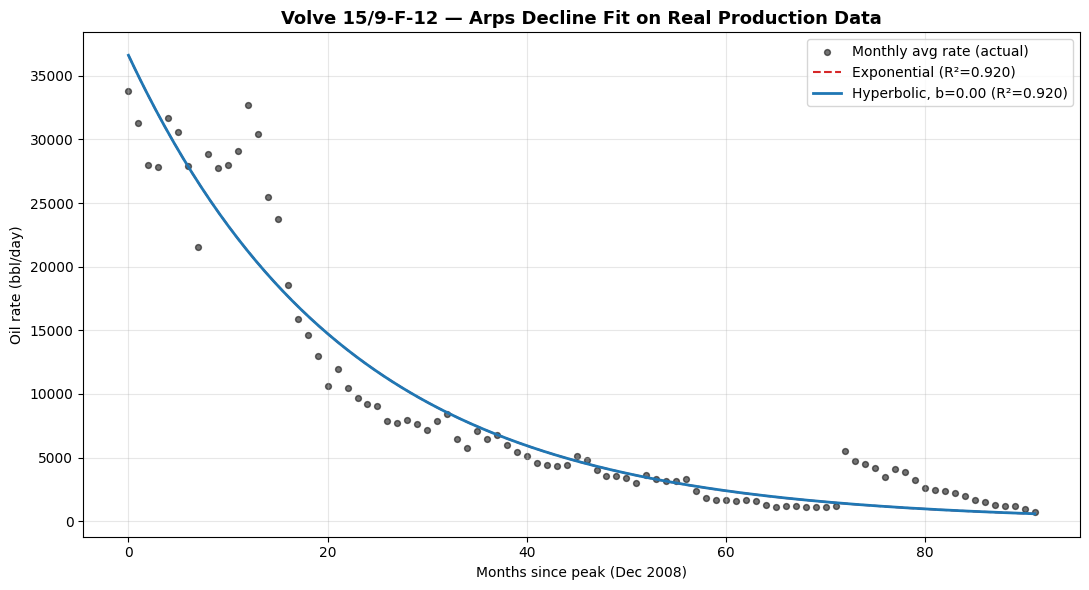

In [49]:
# ============= CELL 6: PLOT =============
plt.figure(figsize=(11, 6))
plt.scatter(t, q, s=18, color="black", alpha=0.55, label="Monthly avg rate (actual)")
tt = np.linspace(0, len(t) - 1, 300)
plt.plot(tt, exponential(tt, *exp_p), "--", color="tab:red",
         label=f"Exponential (R²={r2_e:.3f})")
plt.plot(tt, hyperbolic(tt, *hyp_p), color="tab:blue", lw=2,
         label=f"Hyperbolic, b={hyp_p[2]:.2f} (R²={r2_h:.3f})")
plt.title("Volve 15/9-F-12 — Arps Decline Fit on Real Production Data",
          fontsize=13, fontweight="bold")
plt.xlabel(f"Months since peak ({peak_date:%b %Y})")
plt.ylabel("Oil rate (bbl/day)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("volve_f12_dca.png", dpi=150)
plt.show()

## 7. Sanity check against reality

Model cumulative over the decline period (~24.1 MMbbl) vs actual
cumulative from the raw data (~28.6 MMbbl). The gap is mostly the
pre-peak ramp period excluded from the fit. Checking a model against
ground truth — not just its R² — is the habit this project is
really about.

In [50]:
# ============= CELL 7: SANITY CHECK vs REALITY =============
# The well produced until Sep 2016. Compare fitted cumulative vs actual.
actual_cum_bbl = well["BORE_OIL_VOL"].sum() * 6.2898
fit_cum_bbl = np.trapezoid(hyperbolic(t, *hyp_p), t) * 30.4
print(f"Actual cumulative (from data): {actual_cum_bbl:,.0f} bbl")
print(f"Hyperbolic model cumulative:   {fit_cum_bbl:,.0f} bbl (decline period only)")

Actual cumulative (from data): 28,569,791 bbl
Hyperbolic model cumulative:   24,087,581 bbl (decline period only)
